# VQE del modelo de Ising transverso con redes tensoriales

En este notebook construiremos y analizaremos un **Variational Quantum Eigensolver (VQE)** para una cadena de 10 qubits. La energía se evalúa con una representación **Matrix Product State (MPS)** mediante `default.tensor` de PennyLane y Quimb.

Al terminar podremos:

1. identificar el Hamiltoniano y su punto crítico;
2. preparar el estado inicial $|0101010101\rangle$;
3. entender el ansatz variacional y la función de costo;
4. interpretar la convergencia, el error energético y la dimensión de enlace MPS.

## 1. Modelo físico

Usaremos el modelo de Ising antiferromagnético unidimensional con campo transverso y fronteras abiertas:

$$H = J\sum_{i=0}^{N-2} Z_iZ_{i+1} - h\sum_{i=0}^{N-1}X_i.$$

- $J>0$ favorece que qubits vecinos apunten en direcciones opuestas en la base $Z$.
- $h>0$ favorece la alineación en la dirección $+X$.
- En el límite termodinámico, la transición cuántica ocurre en $h/J=1$.

Para $N=10$ no existe una singularidad perfecta: observamos una versión suavizada por el tamaño finito. Elegimos $J=h=1$, justo en esa razón crítica.

## 2. Preparación del entorno

Las variables de entorno se establecen antes de importar PennyLane y Quimb. Limitamos los hilos porque estas contracciones pequeñas suelen ser más rápidas sin paralelismo anidado. La caché Numba se desactiva para que el ejemplo también funcione en entornos donde los paquetes instalados son de solo lectura.

In [1]:
import os

os.environ.setdefault("QUIMB_NUMBA_CACHE", "OFF")
os.environ.setdefault("QUIMB_NUM_THREAD_WORKERS", "1")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")

import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pennylane as qml
import quimb
from IPython.display import Markdown, display

warnings.filterwarnings(
    "ignore",
    category=np.exceptions.ComplexWarning,
    module=r"pennylane\.devices\.default_tensor",
)

print(f"PennyLane: {qml.__version__}")
print(f"Quimb:     {quimb.__version__}")

PennyLane: 0.45.1
Quimb:     1.15.0


## 3. Parámetros y estado inicial

El bit `0` representa el autovalor $+1$ de $Z$ y el bit `1` representa $-1$. Por eso `0101010101` es un estado de **Néel**: cada pareja vecina tiene $\langle Z_iZ_{i+1}\rangle=-1$ y minimiza el término antiferromagnético cuando $h=0$.

In [2]:
N_QUBITS = 10
J = 1.0
H_FIELD = 1.0
N_LAYERS = 6
MAX_BOND = 64
CUTOFF = 1e-12

initial_state = np.array([site % 2 for site in range(N_QUBITS)], dtype=int)
initial_bitstring = "".join(map(str, initial_state))

print(f"Estado inicial: |{initial_bitstring}>")
print(f"Razón crítica h/J = {H_FIELD / J:.1f}")

Estado inicial: |0101010101>
Razón crítica h/J = 1.0


## 4. Hamiltoniano en PennyLane

Hay nueve interacciones $ZZ$ porque usamos fronteras abiertas y diez términos de campo $X$. En total, la energía es la suma de 19 valores esperados.

In [3]:
def make_tfim_hamiltonian(num_qubits, coupling, field):
    coefficients = [coupling] * (num_qubits - 1) + [-field] * num_qubits
    observables = [
        qml.PauliZ(site) @ qml.PauliZ(site + 1)
        for site in range(num_qubits - 1)
    ]
    observables.extend(qml.PauliX(site) for site in range(num_qubits))
    return qml.Hamiltonian(coefficients, observables)

hamiltonian = make_tfim_hamiltonian(N_QUBITS, J, H_FIELD)
print(hamiltonian)

1.0 * (Z(0) @ Z(1)) + 1.0 * (Z(1) @ Z(2)) + 1.0 * (Z(2) @ Z(3)) + 1.0 * (Z(3) @ Z(4)) + 1.0 * (Z(4) @ Z(5)) + 1.0 * (Z(5) @ Z(6)) + 1.0 * (Z(6) @ Z(7)) + 1.0 * (Z(7) @ Z(8)) + 1.0 * (Z(8) @ Z(9)) + -1.0 * X(0) + -1.0 * X(1) + -1.0 * X(2) + -1.0 * X(3) + -1.0 * X(4) + -1.0 * X(5) + -1.0 * X(6) + -1.0 * X(7) + -1.0 * X(8) + -1.0 * X(9)


## 5. ¿Dónde aparece la red tensorial?

Un vector de estado almacena $2^N$ amplitudes. Una MPS factoriza esas amplitudes en una cadena de tensores:

$$|\psi\rangle \longleftrightarrow A^{[0]}-A^{[1]}-\cdots-A^{[N-1]}.$$

Los enlaces internos tienen dimensión $\chi$, llamada **dimensión de enlace**. Esta mide cuánta correlación debe transportar la representación. El costo crece aproximadamente de forma polinómica con $\chi$, pero $\chi$ puede crecer rápidamente en estados muy entrelazados.

Aquí permitimos $\chi\leq64$ y descartamos valores singulares menores que $10^{-12}$. Para 10 qubits, ese límite es más que suficiente para este circuito.

In [4]:
device = qml.device(
    "default.tensor",
    wires=N_QUBITS,
    method="mps",
    max_bond_dim=MAX_BOND,
    cutoff=CUTOFF,
    contract="auto-mps",
    contraction_optimizer="greedy",
)

print(device)

<default.tensor device (wires=10) at 0x22c9015b4d0>


## 6. Ansatz variacional

Cada capa contiene tres parámetros:

- una rotación $R_Y(\theta_e)$ compartida por los sitios pares;
- una rotación $R_Y(\theta_o)$ compartida por los sitios impares;
- una interacción $\mathrm{IsingZZ}(\phi)$ compartida por los enlaces vecinos.

Con seis capas tenemos solamente $6\times3=18$ parámetros. Las compuertas $ZZ$ se aplican en patrón *brickwork*: primero enlaces pares y después impares. Así todas las operaciones son locales en la cadena MPS. Cuando todos los parámetros valen cero, el circuito deja intacto el estado solicitado.

In [5]:
def ansatz(parameters):
    qml.BasisState(initial_state, wires=range(N_QUBITS))

    for even_angle, odd_angle, entangling_angle in parameters:
        for site in range(N_QUBITS):
            angle = even_angle if site % 2 == 0 else odd_angle
            qml.RY(angle, wires=site)

        for first_site in (0, 1):
            for site in range(first_site, N_QUBITS - 1, 2):
                qml.IsingZZ(entangling_angle, wires=[site, site + 1])

@qml.qnode(device, interface=None)
def energy_circuit(parameters):
    ansatz(parameters)
    return qml.expval(hamiltonian)

zero_parameters = np.zeros((N_LAYERS, 3))
initial_energy = float(energy_circuit(zero_parameters))
print(f"Energía del estado inicial: {initial_energy:.10f}")

Energía del estado inicial: -9.0000000000


La energía inicial es $-9$: cada uno de los nueve enlaces contribuye $-1$ y cada $\langle X_i\rangle$ vale cero en un estado de la base computacional.

## 7. Principio variacional y optimización

El VQE minimiza

$$E(\boldsymbol\theta)=\langle\psi(\boldsymbol\theta)|H|\psi(\boldsymbol\theta)\rangle.$$

El principio variacional garantiza $E(\boldsymbol\theta)\geq E_0$, donde $E_0$ es la energía exacta del estado base. Usamos **COBYLA**, un optimizador clásico sin gradientes. Cada evaluación de la función de costo ejecuta el circuito completo en el backend MPS.

La celda siguiente carga la corrida validada de 400 evaluaciones. Cambia `RUN_FULL_OPTIMIZATION` a `True` si deseas repetirla; tardó alrededor de 75 segundos en esta laptop.

In [6]:
RUN_FULL_OPTIMIZATION = False
RESULTS_PATH = Path("results/vqe_results.json")

if RUN_FULL_OPTIMIZATION:
    from vqe_tfim_mps import run_vqe

    results = run_vqe(
        num_qubits=N_QUBITS,
        layers=N_LAYERS,
        coupling=J,
        field=H_FIELD,
        max_iterations=400,
        max_bond_dimension=MAX_BOND,
        cutoff=CUTOFF,
        seed=7,
        output_directory=Path("results"),
    )
else:
    results = json.loads(RESULTS_PATH.read_text(encoding="utf-8"))
    print("Se cargó la corrida validada de 400 evaluaciones.")

Se cargó la corrida validada de 400 evaluaciones.


## 8. Verificación independiente con la MPS

Cargamos los parámetros optimizados y volvemos a evaluar la energía con el QNode tensorial. Esto comprueba que el número guardado no es solamente texto en un archivo.

In [7]:
optimized_parameters = np.asarray(results["optimized_parameters"], dtype=float)
verified_energy = float(energy_circuit(optimized_parameters))
stored_energy = float(results["final_vqe_energy"])

print(f"Energía almacenada:  {stored_energy:.10f}")
print(f"Energía reevaluada: {verified_energy:.10f}")
print(f"Diferencia:          {abs(verified_energy - stored_energy):.3e}")

Energía almacenada:  -11.8815958574
Energía reevaluada: -11.8815958574
Diferencia:          0.000e+00


## 9. Curva de convergencia

Graficamos la mejor energía encontrada hasta cada evaluación. Una curva descendente indica que el optimizador descubre estados variacionales mejores. La línea roja es la referencia exacta obtenida mediante diagonalización dispersa del sistema pequeño.

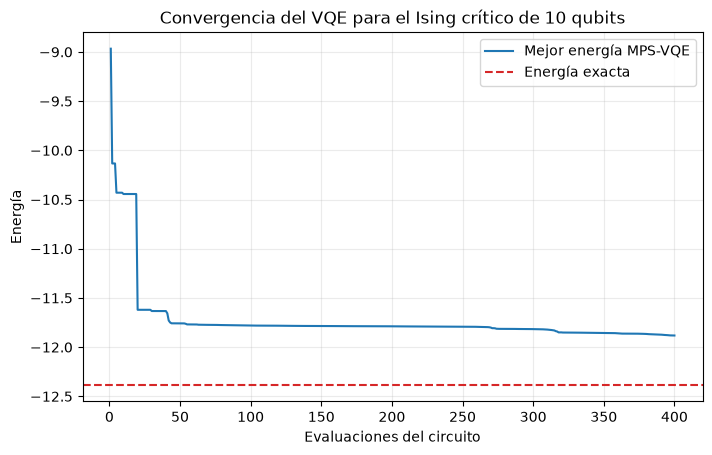

In [8]:
history = np.asarray(results["energy_history"], dtype=float)
best_so_far = np.minimum.accumulate(history)
exact_energy = float(results["exact_ground_energy"])

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(np.arange(1, len(history) + 1), best_so_far, label="Mejor energía MPS-VQE")
ax.axhline(exact_energy, color="tab:red", linestyle="--", label="Energía exacta")
ax.set(
    xlabel="Evaluaciones del circuito",
    ylabel="Energía",
    title="Convergencia del VQE para el Ising crítico de 10 qubits",
)
ax.grid(alpha=0.25)
ax.legend()
plt.show()

## 10. Observables y diagnóstico

Además de la energía registramos:

- $\overline{X}=N^{-1}\sum_i\langle X_i\rangle$, respuesta al campo transverso;
- $m_s^Z=N^{-1}\sum_i(-1)^i\langle Z_i\rangle$, magnetización escalonada asociada al orden antiferromagnético;
- la máxima dimensión de enlace observada, que describe el tamaño efectivo de la MPS.

In [9]:
relative_error_percent = 100 * float(results["relative_energy_error"])

display(Markdown(f"""
| Magnitud | Resultado |
|---|---:|
| Energía inicial | {results['initial_energy']:.6f} |
| Energía MPS-VQE | {results['final_vqe_energy']:.6f} |
| Energía exacta | {results['exact_ground_energy']:.6f} |
| Error relativo | {relative_error_percent:.3f} % |
| $\overline{{X}}$ | {results['mean_transverse_magnetization_X']:.6f} |
| $m_s^Z$ | {results['mean_staggered_magnetization_Z']:.6f} |
| Dimensión de enlace máxima | {results['maximum_bond_dimension_observed']} |
| Tiempo de optimización | {results['runtime_seconds']:.1f} s |
"""))

<>:15: SyntaxWarning: invalid escape sequence '\o'
<>:15: SyntaxWarning: invalid escape sequence '\o'
C:\Users\the_b\AppData\Local\Temp\ipykernel_26696\1226269766.py:15: SyntaxWarning: invalid escape sequence '\o'



| Magnitud | Resultado |
|---|---:|
| Energía inicial | -9.000000 |
| Energía MPS-VQE | -11.881596 |
| Energía exacta | -12.381490 |
| Error relativo | 4.037 % |
| $\overline{X}$ | 0.575183 |
| $m_s^Z$ | 0.816367 |
| Dimensión de enlace máxima | 4 |
| Tiempo de optimización | 75.1 s |


## 11. Interpretación

La optimización redujo la energía de $-9$ a aproximadamente $-11.882$. La referencia exacta es $-12.381$, de modo que el error relativo es cercano al 4 %.

La dimensión de enlace máxima observada fue $\chi=4$, muy por debajo del límite 64. Esto indica que el error no se debe principalmente a truncar la MPS. Los factores dominantes son la expresividad del ansatz de 18 parámetros y que COBYLA alcanzó el límite de 400 evaluaciones mientras la energía todavía descendía lentamente.

Este es también un ejemplo útil del principio variacional: la energía aproximada permanece por encima de la energía exacta.

## 12. Experimentos sugeridos

1. Aumenta `N_LAYERS` y observa si mejora la energía y crece $\chi$.
2. Repite el VQE con $h/J=0.5$ y $h/J=1.5$ para explorar ambos lados de la transición.
3. Cambia el estado inicial y compara la dificultad de optimización.
4. Incrementa las evaluaciones de COBYLA o prueba otro optimizador.
5. Reduce `MAX_BOND` deliberadamente para estudiar el error de truncamiento.

La separación importante es: **VQE** controla qué estado variacional buscamos; **MPS** controla cómo representamos y contraemos ese estado clásicamente.